# 05 · Exploratory Data Analysis

Summary statistics, adoption trajectories, and grid-stress trends.

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / 'src'))

PROC = ROOT / 'data' / 'processed'
FIGS = ROOT / 'output' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

panel = pd.read_parquet(PROC / 'panel_for_regression.parquet')

## 5.1 Summary Statistics

In [2]:
key_vars = ['btm_capacity_kw', 'ramp_magnitude_mwh', 'curtailment_days_per_month', 'negative_lmp_hours_per_month']
panel[key_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
btm_capacity_kw,174744.0,2.735017e+03,5348.506719,0.0,42.817,6.057956e+02,2.901318e+03,6.547243e+04
ramp_magnitude_mwh,173126.0,1.608467e+06,945771.380182,3448.0,1003698.000,1.504776e+06,2.168906e+06,5.122723e+06
curtailment_days_per_month,174744.0,0.000000e+00,0.000000,0.0,0.000,0.000000e+00,0.000000e+00,0.000000e+00
negative_lmp_hours_per_month,174744.0,0.000000e+00,0.000000,0.0,0.000,0.000000e+00,0.000000e+00,0.000000e+00


In [3]:
# By utility territory
panel.groupby('utility')[key_vars].mean().round(2)

,btm_capacity_kw,ramp_magnitude_mwh,curtailment_days_per_month,negative_lmp_hours_per_month
utility,,,,
Pacific Gas & Electric Company,2560.88,1608466.82,0.0,0.0
San Diego Gas & Electric,6938.46,1608466.82,0.0,0.0
Southern California Edison,3441.53,1608466.82,0.0,0.0


## 5.2 Adoption Growth Trajectory

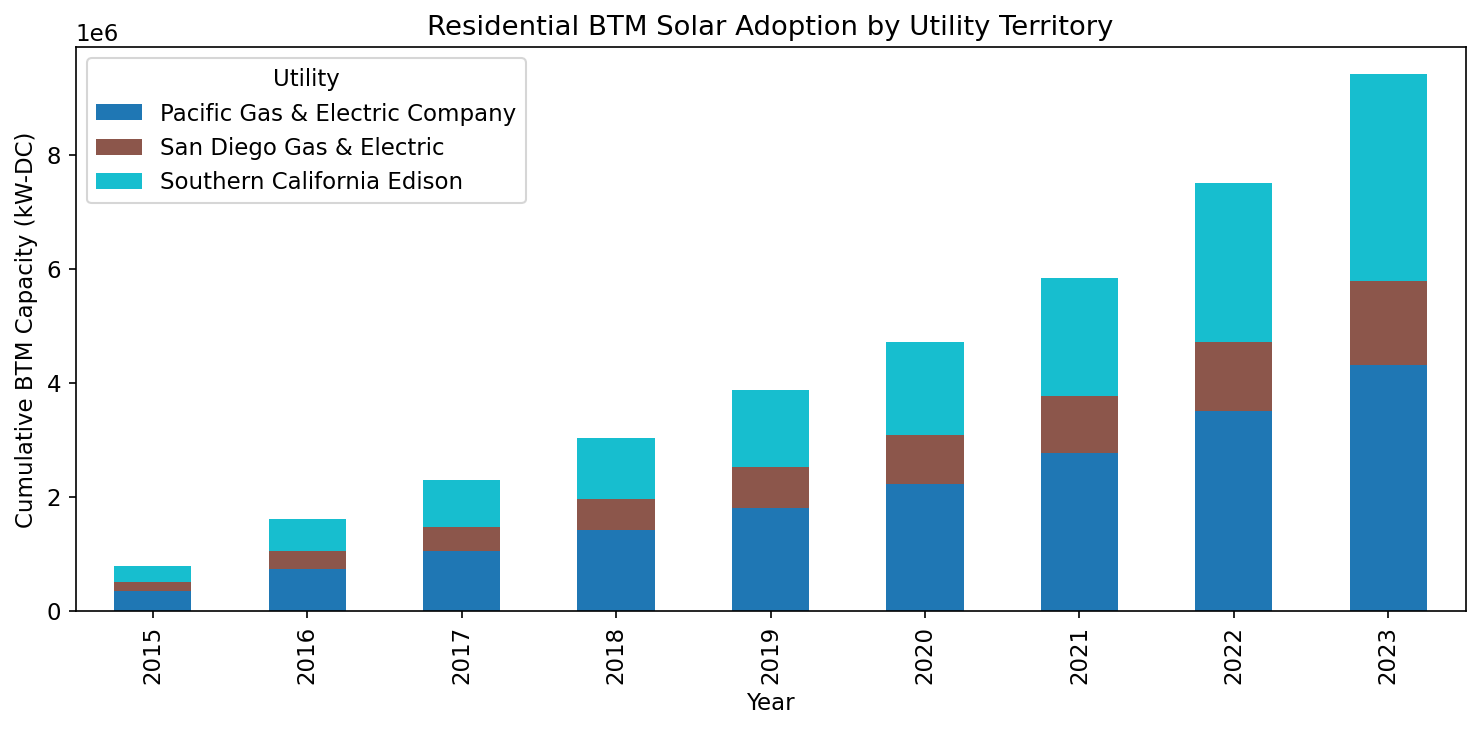

In [4]:
annual_cap = panel[panel['month'] == 12].groupby(['year', 'utility'])['btm_capacity_kw'].sum().unstack('utility').fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
annual_cap.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative BTM Capacity (kW-DC)')
ax.set_title('Residential BTM Solar Adoption by Utility Territory')
ax.legend(title='Utility')
plt.tight_layout()
fig.savefig(FIGS / 'adoption_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

## 5.3 Grid-Stress Trends

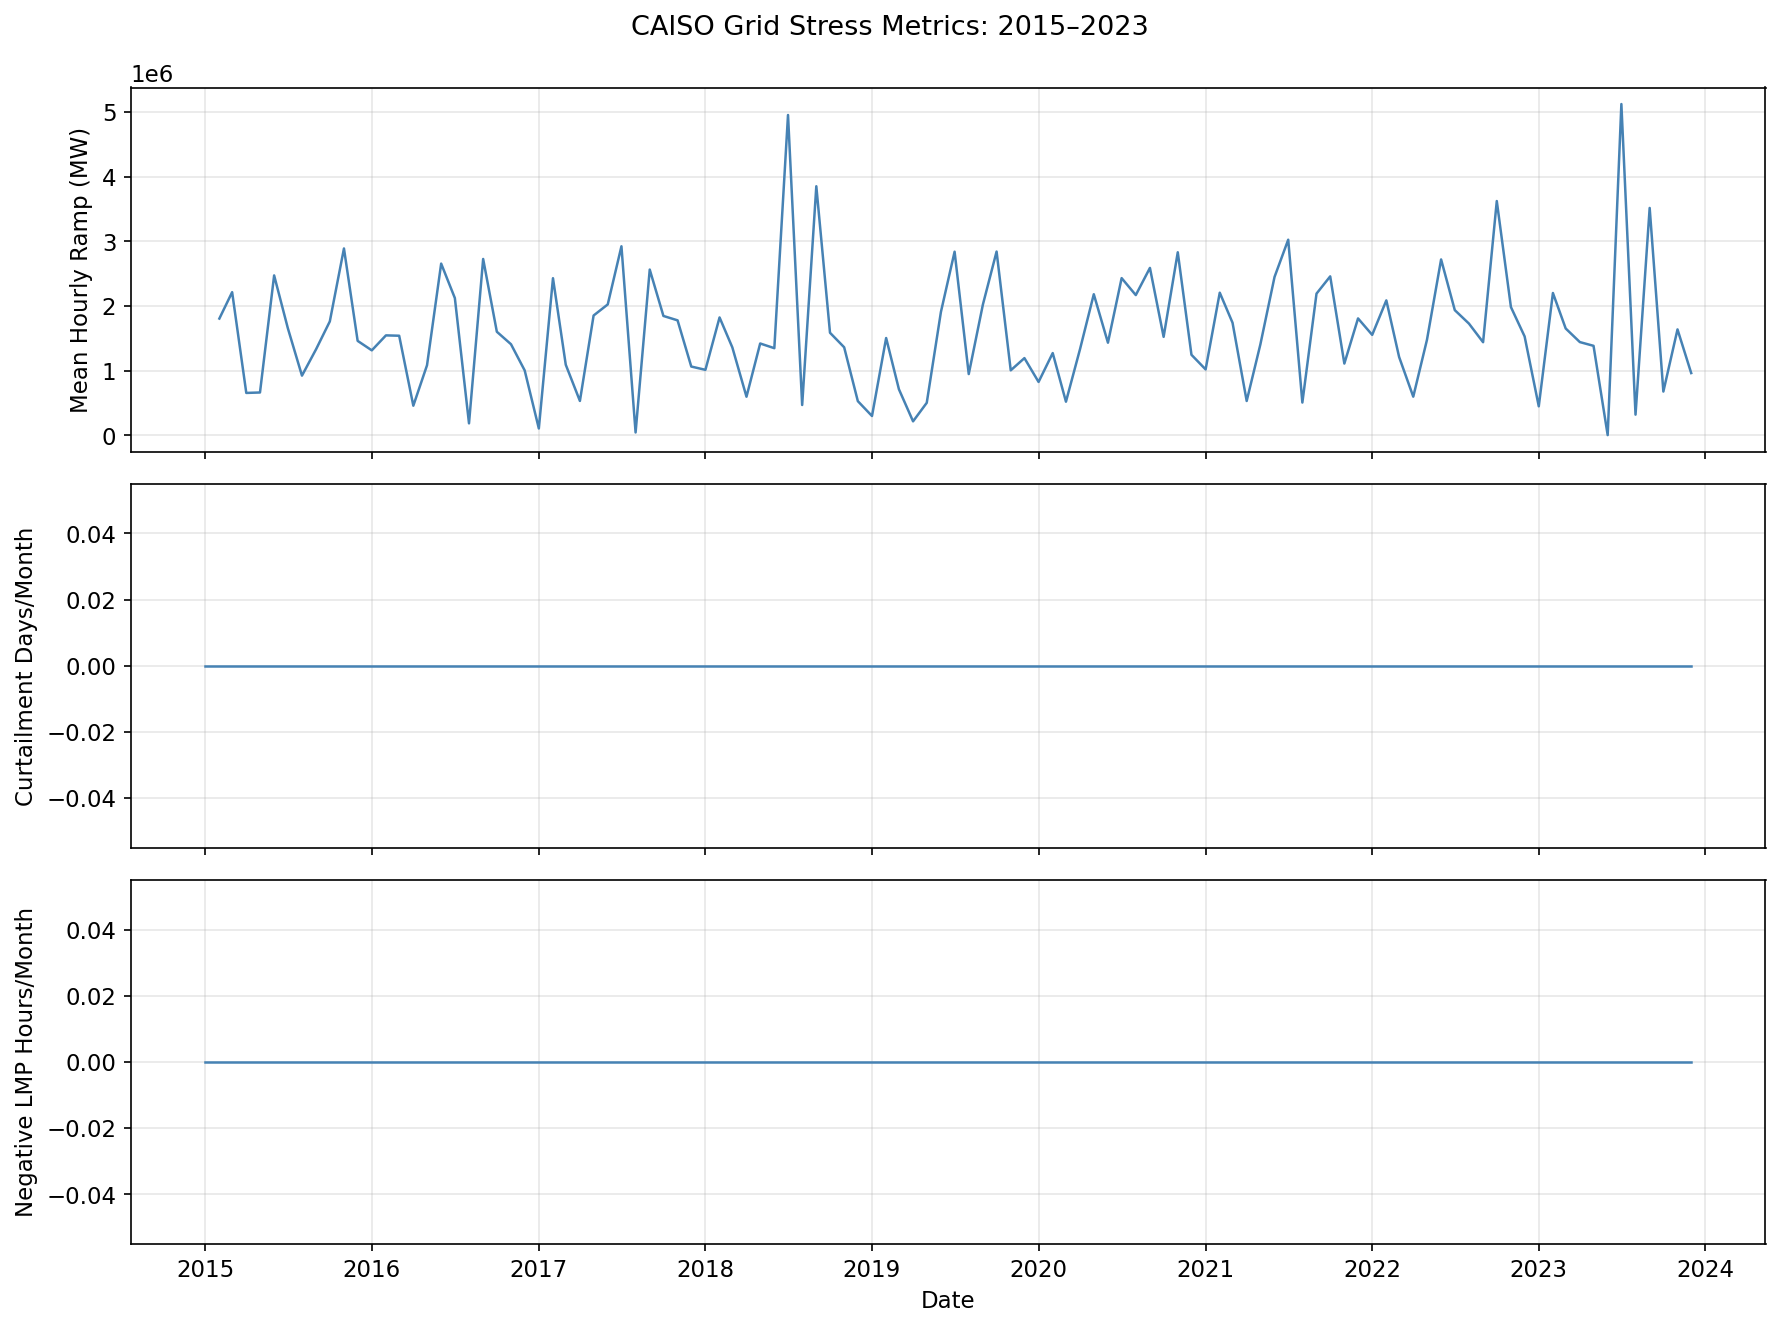

In [5]:
monthly_avg = panel.groupby(['year', 'month'])[['ramp_magnitude_mwh', 'curtailment_days_per_month', 'negative_lmp_hours_per_month']].mean().reset_index()
monthly_avg['date'] = pd.to_datetime(monthly_avg[['year', 'month']].assign(day=1))

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, col, label in zip(
    axes,
    ['ramp_magnitude_mwh', 'curtailment_days_per_month', 'negative_lmp_hours_per_month'],
    ['Mean Hourly Ramp (MW)', 'Curtailment Days/Month', 'Negative LMP Hours/Month']
):
    ax.plot(monthly_avg['date'], monthly_avg[col], linewidth=1.2, color='steelblue')
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('CAISO Grid Stress Metrics: 2015–2023', fontsize=13)
plt.tight_layout()
fig.savefig(FIGS / 'grid_stress_trends.png', dpi=300, bbox_inches='tight')
plt.show()

## 5.4 Correlation Matrix

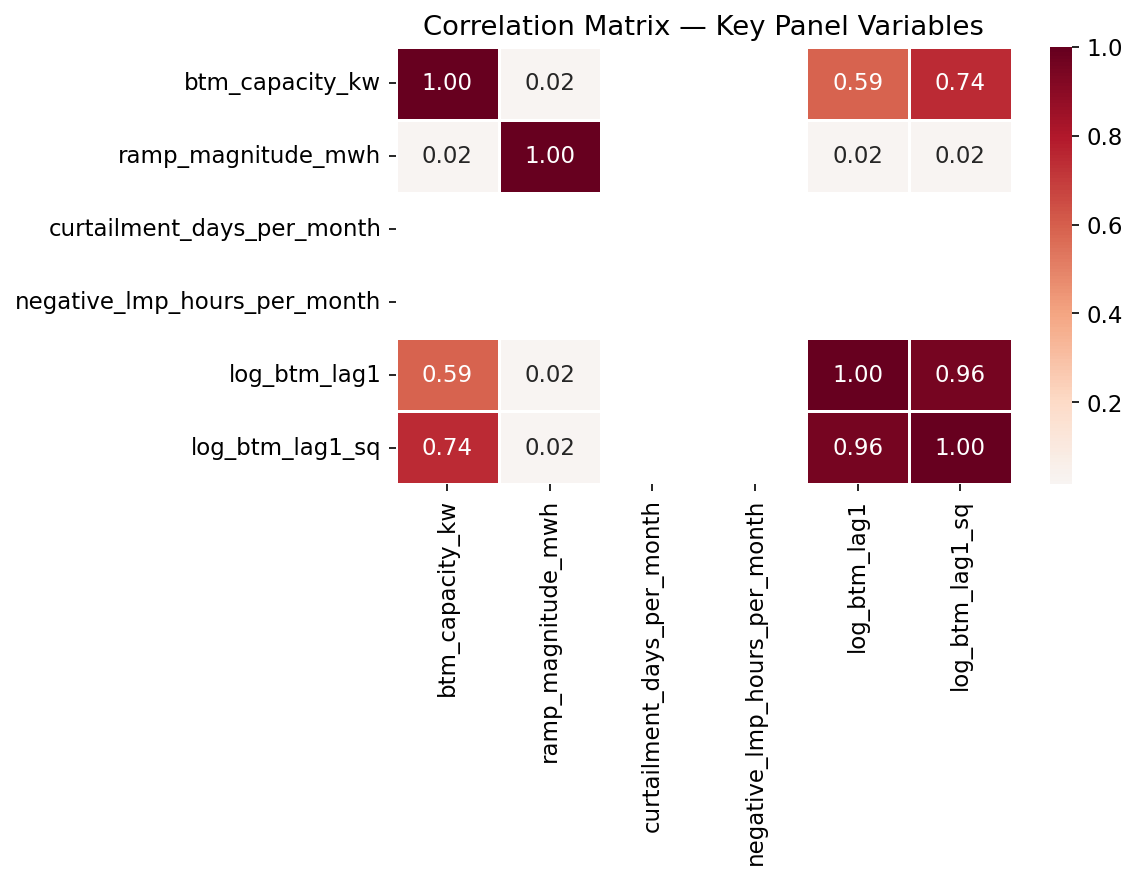

In [6]:
corr_vars = [c for c in key_vars + ['log_btm_lag1', 'log_btm_lag1_sq'] if c in panel.columns]
corr = panel[corr_vars].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Key Panel Variables')
plt.tight_layout()
fig.savefig(FIGS / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 5.5 BTM Capacity Distribution by ZIP

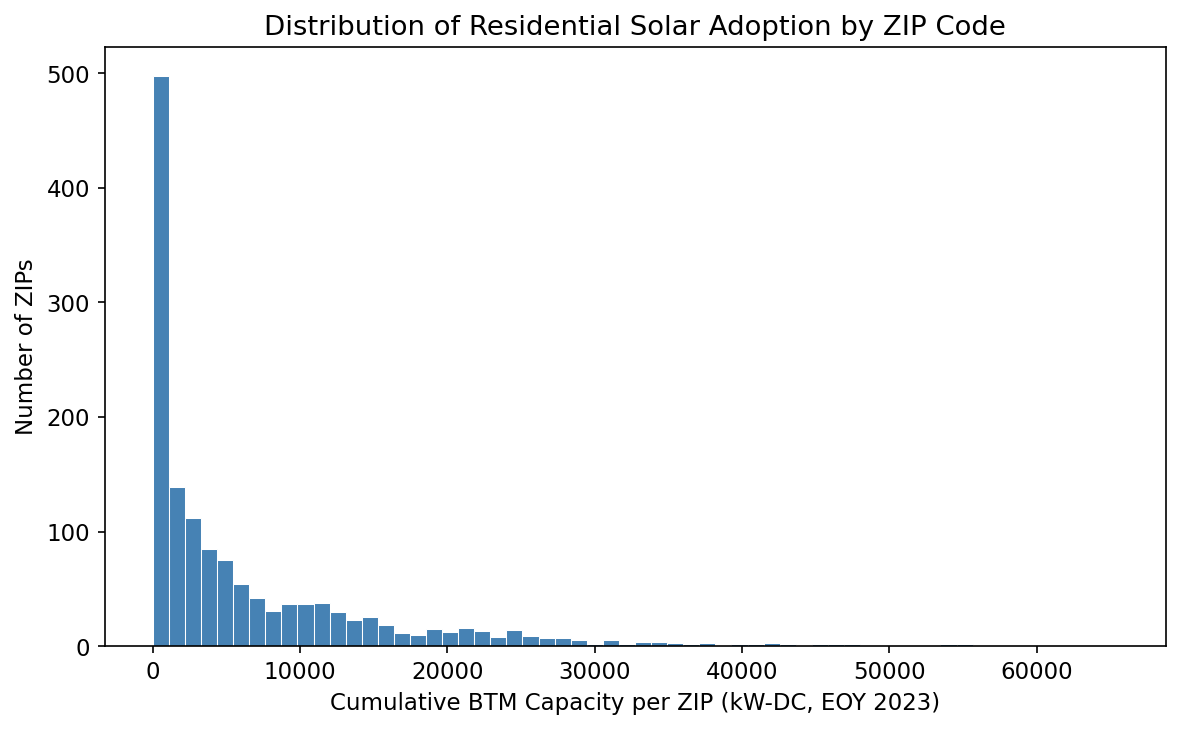

In [7]:
latest = panel[panel['year'] == 2023].groupby('zip_code')['btm_capacity_kw'].max()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(latest[latest > 0], bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Cumulative BTM Capacity per ZIP (kW-DC, EOY 2023)')
ax.set_ylabel('Number of ZIPs')
ax.set_title('Distribution of Residential Solar Adoption by ZIP Code')
plt.tight_layout()
fig.savefig(FIGS / 'btm_distribution_by_zip.png', dpi=300, bbox_inches='tight')
plt.show()